In [1]:

# Machine Learning / Deep Learning

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.layers import Dropout

# Configuración del entorno
import json
import os
import warnings
import re
import numpy as np
import pandas as pd

os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

warnings.filterwarnings("ignore")

tf.random.set_seed(42)
np.random.seed(42)


# modelado 

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error
)


# Estadística de series temporales

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


# Visualización

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import plotly.graph_objects as go

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("viridis")


# Optimización

import optuna
import optuna.visualization as vis


In [2]:
# generación automatica de semillas para la reproductibilidad

tf.random.set_seed(42)
np.random.seed(42)

In [3]:
# carga de datos desde lakehouse 
#data_prices_syp = spark.sql("select * from lakehouse_dataprices.`S&P500_data` order by Date ASC").toPandas()
#data_nvidia = spark.sql("select * from lakehouse_dataprices.nvidia_data order by Date ASC").toPandas()
#data_vix = spark.sql("select * from lakehouse_dataprices.vix_data order by Date ASC").toPandas()

In [4]:
# carga de datos desde archivos csv
# se descomentan solo los de nvidia y syp 
tickets = [
    "NVDA",
    "^SPX"
    #"AMD",
    #"BTC-USD",
    #"^NDX",
    #"^VIX",
    #"UBSFY"
]
# se cargan las fechas
dates = pd.read_csv("../data/csv/SPX_data.csv")
# se crea un dataframe con las fechas de close para almacenar los precios de cierre
date_close = pd.DataFrame({
    "Date": pd.to_datetime(dates["Date"])
})

# se recorren los tickets, se lee el archivo asociado al ticket y se
# carga en el df el precio de cierre

for ticket in tickets: 
    file_name = ticket.replace("^", "") # se quita el caracter ^
    data_ticket = pd.read_csv(f"../data/csv/{file_name}_data.csv") # se lee el archivo csv del ticket correspondiente
    data_ticket["Date"] = pd.to_datetime(data_ticket["Date"]) # se formatea la columna Date a fecha

    # se define el nombre de la columna de precios de cierre
    close_column = f"{file_name}_Close"

    # se hace left join del df de las fechas con el df del ticket creado, por fechas
    date_close = pd.merge(
        date_close, # primer df
        data_ticket[["Date", close_column]].rename(columns={close_column: file_name}),
        # se escogen las columnas date y cierre del df del ticket y se renombra la columna de precio de cierre con el nombre del ticket
        on="Date", # columna para hacer el merge
        how="left" # tipo de merge
    )

In [5]:
df_data_close = pd.DataFrame(date_close.copy()) # copia del df de precios de cierre como df
df_dat_close = df_data_close.sort_values(by="Date", ascending=True) # se ordena por fecha ascendente
df_data_close.head()

,Date,NVDA,SPX
0,2021-01-04,13.077453,3700.649902
1,2021-01-05,13.367903,3726.860107
2,2021-01-06,12.579823,3748.139893
3,2021-01-07,13.307318,3803.790039
4,2021-01-08,13.240255,3824.679932


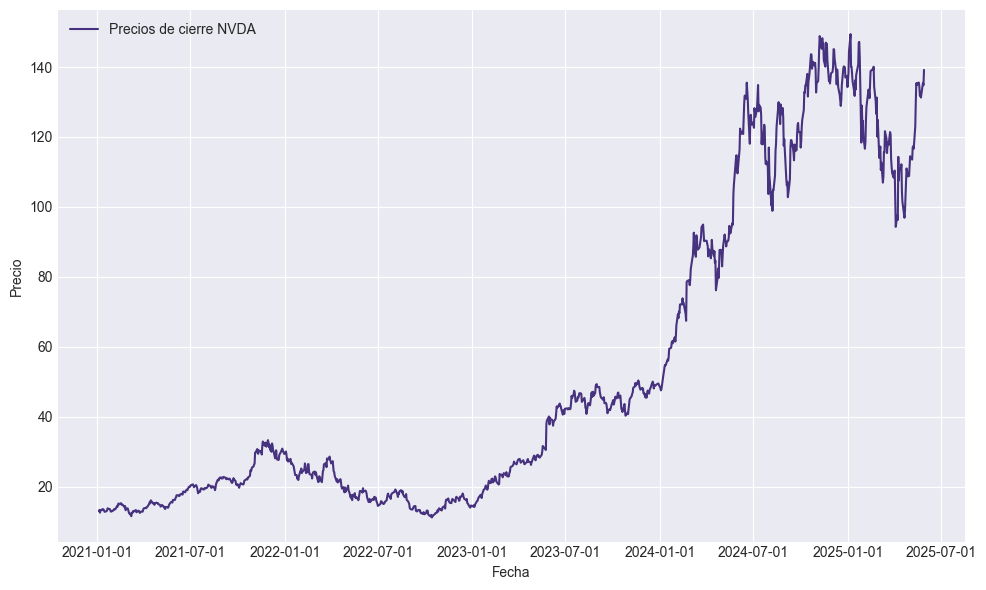

In [6]:
# se grafican los datos de cierre de la serie 
plt.figure(figsize=(10,6))
plt.plot(df_data_close["Date"], df_data_close["NVDA"], label="Precios de cierre NVDA")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()

# esta parte es para que las fechas en el eje x se vean mejor
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator()) # se ajusta el espaciado de las fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) # se formatea la fechas
plt.grid(True)
plt.tight_layout()# se ajusta el layout para que no se corten los elementos
plt.show()

In [7]:
# se hace una copia para la manipulación de los datos y se deja un porcentaje para extrapolar el comportamiento del modelo
df_data_close_copy = df_data_close.copy()
percentage = 0.9 # porcentaje de datos para folds
folds_data_size = int(len(df_data_close_copy) * percentage) # tamaño de los datos para folds
folds_data = df_data_close_copy.iloc[:folds_data_size] # datos para folds
val_data = df_data_close_copy.iloc[folds_data_size:] # datos para validación final

# se calcula la fecha donde se toman los datos de validación
val_start_date = folds_data["Date"][-1:].values[0]
folds_data.tail()

,Date,NVDA,SPX
990,2024-12-10,135.040588,6034.910156
991,2024-12-11,139.279648,6084.189941
992,2024-12-12,137.310089,6051.250000
993,2024-12-13,134.220764,6051.089844
994,2024-12-16,131.971237,6074.080078


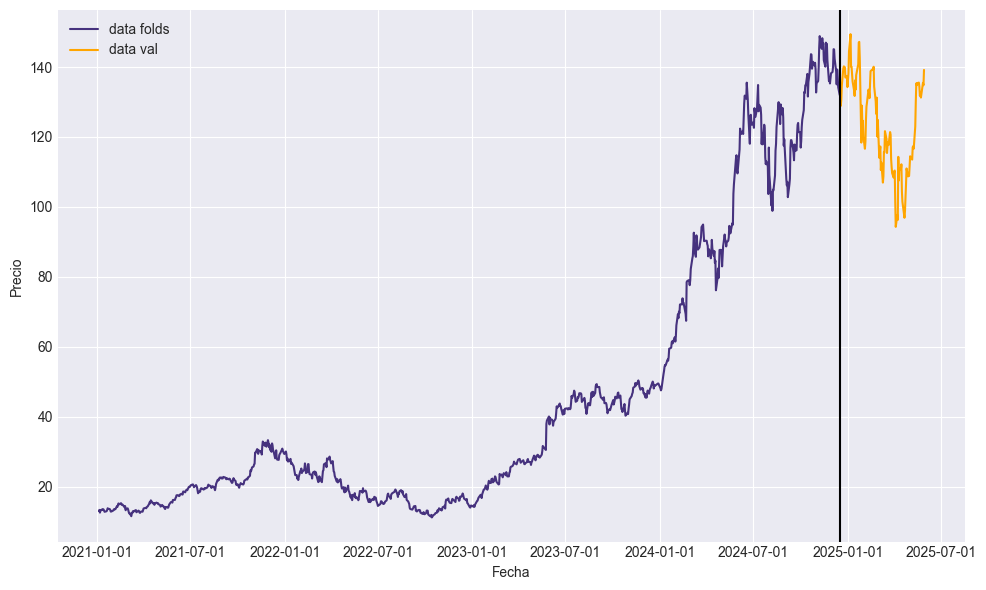

In [8]:
# se grafican los datos de cierre de la serie 
plt.figure(figsize=(10,6))
plt.plot(folds_data["Date"], folds_data["NVDA"], label="data folds")
plt.plot(val_data["Date"], val_data["NVDA"], label="data val", color='orange')
plt.axvline(val_start_date, color="black")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()

# esta parte es para que las fechas en el eje x se vean mejor
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator()) # se ajusta el espaciado de las fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) # se formatea la fechas
plt.grid(True)
plt.tight_layout()# se ajusta el layout para que no se corten los elementos
plt.show()

In [9]:
# se escogen los valores y se normalizan (TODOS) por lo que en este caso tambien se normalizan los de prueba
# se les da tambien la forma requerida (redimensionado) (se ponen los de pruea igual pero solo se
# usaran los datos de folds)

scaler = MinMaxScaler(feature_range=(0,1))

# para el caso en el que solo se toma una variable
# data_folds_values = folds_data[["NVDA"]].values.reshape(-1,1)
# data_val_values = val_data[["NVDA"]].values.reshape(-1,1)
# para dos o mas
data_folds_values = folds_data[["NVDA", "SPX"]].values.reshape(-1,2)
data_val_values = val_data[["NVDA", "SPX"]].values.reshape(-1,2)
print(data_folds_values)
df_data_close.head()

[[  13.07745266 3700.64990234]
 [  13.36790276 3726.86010742]
 [  12.57982349 3748.13989258]
 ...
 [ 137.31008911 6051.25      ]
 [ 134.22076416 6051.08984375]
 [ 131.97123718 6074.08007812]]


,Date,NVDA,SPX
0,2021-01-04,13.077453,3700.649902
1,2021-01-05,13.367903,3726.860107
2,2021-01-06,12.579823,3748.139893
3,2021-01-07,13.307318,3803.790039
4,2021-01-08,13.240255,3824.679932


In [10]:
# se normalizan los datos con el escalador definido
scaled_data_folds = scaler.fit_transform(data_folds_values)
scaled_data_val = scaler.transform(data_val_values)
scaled_data_folds

array([[0.01354362, 0.04918745],
       [0.01565409, 0.0596163 ],
       [0.00992776, 0.06808338],
       ...,
       [0.91624096, 0.98447422],
       [0.89379336, 0.98441049],
       [0.87744788, 0.99355814]])

In [11]:
# Ahora se crea la función que creará las ventanas con los rezagos para ingresar en la red.
# para que la RNN reciba los datos como un tensor de orden 3
# la función crea un dataset para los datos de entrenamiento de la RNN.
# create_dataset es una función que genera los datos de entrada X y los datos de salida y
# se crea una ventana de datos de tamaño 1 (pero este será un hiperparámetro de la red) sobre los precios y se almacena
# el próximo precio como objetivo. El array X es redimensionado como un array 3D como lo requiere la RNN:
# [samples, time_steps, features] 

def create_dataset(data, time_step=1):
    X, y = [], [] # se crean dos arrays vacíos que devolverán los datos separados por ventanas
    for i in range(len(data) - time_step - 1):
        arr_2_add = data[i : (i + time_step), :]
        # print(len(arr_2_add))
        X.append(arr_2_add)
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

# ejemplo
X_example, y_example = create_dataset(scaled_data_folds)
X_example = X_example.reshape(X_example.shape[0], X_example.shape[1], X_example.shape[2])
X_example[0]

array([[0.01354362, 0.04918745]])

In [ ]:
# se define ahora una función que ayudará a construir la rnn de forma paramétrica,
# input_timesteps: numero de rezagos
# n_features: numero de características (variables exogenas + variables objetivo)
# units: numero de unidades de la capa recurrente
# lr: tasa de aprendizaje
def build_rnn(input_timesteps, n_features, units, lr,  dropout_rate=0.2, recurrent_dropout_rate=0.1):
    model = models.Sequential() # se inicializa el modelo
    model.add(layers.Input(shape=(input_timesteps, n_features))) # se añade la capa de entrada, son las n_features
    # cada una con dimensión input_timesteps
    model.add(layers.SimpleRNN(
        units=units, 
        activation="tanh", 
        stateful=False,
        dropout=dropout_rate,                # regularización en las entradas
        recurrent_dropout=recurrent_dropout_rate  # regularización en las conexiones internas
        )
    ) # se añade la capa RNN con las unidades y función de activación tanh
    model.add(layers.Dense(units=1, activation="linear")) # se añade la capa densa de salida con una neurona y función de activación lineal
    model.compile(
        optimizer = optimizers.Adam(learning_rate=lr), # se compila el modelo con el optimizador Adam y la tasa de aprendizaje lr
        loss = "mean_squared_error" # se utiliza el error cuadrático medio como función de pérdida
    )

    return model
# el modelo tiene una neurona de salida. SIn embargo, al usar la definición por ventanas, se toman secuencias de una longitud que tienen 
# como etiqueta otro valor, por lo que el resultado es una neurona pero devuelve un vector

In [13]:
# se muestra de forma visual como funcionan los folds
# si no se define el tamaño de test, en la primera iteracion se toma igual cantidad de datos para train que para test
# por eso se toman los folds de prueba como de la longitud de datos de validación
size_test = len(val_data)
gap = 8 # distancia (cantidad de observaciones) que se deja entre train y test
tscv = TimeSeriesSplit(test_size=size_test, gap=gap)

folds, indexes, types = [], [], []

for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(scaled_data_folds)):
    folds.extend([fold_idx] * len(train_idx)) 
    indexes.extend(train_idx)
    types.extend(['Train'] * len(train_idx))

    folds.extend([fold_idx] * len(test_idx))
    indexes.extend(test_idx)
    types.extend(['Test'] * len(test_idx))

# figura con plotly
fig = go.Figure()

# data train
fig.add_trace(go.Scatter(
    x=indexes, y=folds,
    mode='markers',
    marker=dict(color=['blue' if t == 'Train' else 'orange' for t in types], size=6),
    text=types,
    hovertemplate='Index: %{x}<br> Fold: %{y}<br> Tipo: %{text}<extra></extra>'
))

fig.update_layout(
    title='Folds',
    xaxis_title='Indices serie',
    yaxis_title='Fold',
    yaxis=dict(autorange='reversed'),
    legend_title='Tipo de conjunto',
    template='plotly_white',
    height=400
)
fig.show()

In [14]:
X_example

array([[[0.01354362, 0.04918745]],

       [[0.01565409, 0.0596163 ]],

       [[0.00992776, 0.06808338]],

       ...,

       [[0.89975035, 0.97797271]],

       [[0.93055214, 0.99758078]],

       [[0.91624096, 0.98447422]]])

In [15]:
# visualizacion de los folds 
# se muestra de forma visual como funcionan los folds
# si no se define el tamaño de test, en la primera iteracion se toma igual cantidad de datos para train que para test
# por eso se toman los folds de prueba como de la longitud de datos de validación
size_test = len(val_data)
gap = 8 # distancia (cantidad de observaciones) que se deja entre train y test
tscv = TimeSeriesSplit(test_size=size_test, gap=gap)

folds, indexes, types = [], [], []

for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(folds_data)):
    folds.extend([fold_idx] * len(train_idx)) 
    indexes.extend(train_idx)
    types.extend(['Train'] * len(train_idx))

    folds.extend([fold_idx] * len(test_idx))
    indexes.extend(test_idx)
    types.extend(['Test'] * len(test_idx))

# figura con plotly
fig = go.Figure()

# data train
fig.add_trace(go.Scatter(
    x=indexes, y=folds,
    mode='markers',
    marker=dict(color=['blue' if t == 'Train' else 'orange' for t in types], size=6),
    text=types,
    hovertemplate='Index: %{x}<br> Fold: %{y}<br> Tipo: %{text}<extra></extra>'
))

fig.update_layout(
    title='Folds',
    xaxis_title='Indices serie',
    yaxis_title='Fold',
    yaxis=dict(autorange='reversed'),
    legend_title='Tipo de conjunto',
    template='plotly_white',
    height=400
)
fig.show()

# Función de optimización

Mediante el uso de Optuna (una librería basada en técnicas de optimización bayesiana secuencial) se define una función de optimización que utiliza validación cruzada temporal para minimizar una métrica de error (en este caso, el MAPE*).

La función está dada de la siguiente forma: primero, se definen los hiperparámetros de la rnn: número de rezagos, unidades recurrentes, tasa de aprendizaje, tamaño de lote y número de épocas.   Para cada uno de estos parámetros se especifican rangos o conjuntos discretos de valores que Optuna explorará con el fin de encontrar la combinación que minimice el error promedio.

Posteriormente, se inicializan listas que almacenarán las métricas de evaluación obtenidas en cada fold (MAPE, MAE y RMSE).  
Durante cada iteración del proceso de validación cruzada, se realiza lo siguiente:
0. se definen los conjuntos train/test de acuerdo con ese fold
1. Se instancia un nuevo modelo RNN con el conjunto de hiperparámetros seleccionados para el trial actual.  
2. Se entrena el modelo sobre el conjunto de entrenamiento definido para ese fold.  
3. Se evalúa el modelo sobre el conjunto de prueba correspondiente, calculando las métricas de error.  

Este proceso se repite para los *k* folds (en este caso, 5), produciendo un conjunto de errores por fold:

- Fold₁ → MAPE₁  
- Fold₂ → MAPE₂  
- Fold₃ → MAPE₃  
- Fold₄ → MAPE₄  
- Fold₅ → MAPE₅  

Así se obtiene el MAPE promedio de los cinco folds:$$ \text{MAPE}_{prom} = \frac{1}{5} \sum_{i=1}^{5} \text{MAPE}_i $$

Este valor se devuelve como resultado de la función objetivo, y representa el desempeño promedio del modelo bajo ese conjunto de hiperparámetros. Optuna repite este proceso en múltiples trials, cada uno con una combinación diferente de hiperparámetros, y selecciona el conjunto que minimiza el MAPE promedio obtenido.


In [16]:
""" # ORIGINAL 
# se define la función objetivo para Optuna
# se buscará optimizar el mape promedio por fold. 
def objective(trial):
    # rangos de los parámetros del modelo
    input_timesteps = trial.suggest_categorical('input_timesteps', [2,7,11,15,20]) # rezagos
    units = trial.suggest_int('units', 16, 128, step=16) # neuronas de la capa recurrente
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True) # learning rate
    batch = trial.suggest_categorical('batch_size', [16, 32, 64]) #cantidad de ejemplos por iteracion
    epochs = trial.suggest_int('epochs', 30, 100) # epocas de entrenamiento

    # validación cruzada
    # se parten las ibservaciones por rezagos con la función create_dataset 
    X_fold, y_fold = create_dataset(scaled_data_folds, input_timesteps)
    # para una feature:  
    # X_fold.reshape(X_fold.shape[0], X_fold.shape[1], 1)
    X_fold = X_fold.reshape(X_fold.shape[0], X_fold.shape[1], X_fold.shape[2])  # asegura forma 3D requerida por la RNN

    # metricas por fold y por trial
    mapes, maes, rmses = [], [], []
    fold_metrics = []

    # se recorre cada fold, así como el par id_train, id_test
    for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(X_fold)):
        tf.random.set_seed(42)
        np.random.seed(42)

        # se escogen pares de datos train/test. 
        # de X_train se escoge la ventana que tiene como tag/resultado correspondiente y_train
        X_train, y_train = X_fold[train_idx], y_fold[train_idx].reshape(-1,1)
        X_test, y_test = X_fold[test_idx], y_fold[test_idx].reshape(-1,1)

        # para una variable
        #X_train, y_train = X[train_idx], y[train_idx].reshape(-1, 1)
        #X_test, y_test = X[test_idx], y[test_idx].reshape(-1, 1)

        # se define la cantidad de features, en este caso esta línea da 2

        # lee la dimensión del array mas interno, para definir la cantidad de features
        n_features = X_train.shape[-1]

        # se construye el modelo
        model = build_rnn(input_timesteps, n_features, units, lr)
        # se fija el modelo a los datos de entrenamiento por fold
        model.fit(
            X_train, y_train,
            epochs=epochs,
            shuffle=False, # no escoja datos de forma aleatoria (de train) sino que respete el orden
            batch_size=batch,
            verbose=0
        )

        # predicción y reescalado de los datos
        y_pred = model.predict(X_test, verbose=0)
        #y_pred_inv = scaler.inverse_transform(y_pred)
        #y_true_inv = scaler.inverse_transform(y_test)

        # al ingresar dos variables, se espera que se tengan esas mismas dos columnas
        # para desescalar, dado que se usó un mismo escalado. 
        # para ambas. Por ello se crea la segunda columna de ceros y se desescala
        # toda la matriz nueva y al final se escoje la primera columna 
        y_pred_inv = scaler.inverse_transform(
            np.hstack([y_pred, np.zeros((len(y_pred), X_fold.shape[2] - 1))])
        )[:,0]

        y_true_inv = scaler.inverse_transform(
            np.hstack([y_test.reshape(-1, 1), np.zeros((len(y_test), X_fold.shape[2]-1))])
        )[:, 0]
        # errores por trial y por fold
        mae = mean_absolute_error(y_true_inv, y_pred_inv)
        mape = mean_absolute_percentage_error(y_true_inv, y_pred_inv)
        rmse = float(np.sqrt(mean_squared_error(y_true_inv, y_pred_inv)))

        # se guardan en los arrays
        mapes.append(mape)
        maes.append(mae)
        rmses.append(rmse)

        # se actualiza el listado de metricas de fold
        fold_metrics.append({
            "fold": fold_idx + 1,
            "mae": mae,
            "mape": mape,
            "rmse": rmse,
            "array_mapes": mapes,
            "array_maes": maes,
            "array_rmses": rmses,
        })

        # se definen los atributos de usuario en optuna y se registra la metrica promedio
        trial.set_user_attr(f"fold_{fold_idx + 1}_metrics", fold_metrics[-1])
        trial.report(np.mean(mapes), step=fold_idx)
    
    return float(np.mean(mapes))

 """

' # ORIGINAL \n# se define la función objetivo para Optuna\n# se buscará optimizar el mape promedio por fold. \ndef objective(trial):\n    # rangos de los parámetros del modelo\n    input_timesteps = trial.suggest_categorical(\'input_timesteps\', [2,7,11,15,20]) # rezagos\n    units = trial.suggest_int(\'units\', 16, 128, step=16) # neuronas de la capa recurrente\n    lr = trial.suggest_float(\'lr\', 1e-4, 1e-2, log=True) # learning rate\n    batch = trial.suggest_categorical(\'batch_size\', [16, 32, 64]) #cantidad de ejemplos por iteracion\n    epochs = trial.suggest_int(\'epochs\', 30, 100) # epocas de entrenamiento\n\n    # validación cruzada\n    # se parten las ibservaciones por rezagos con la función create_dataset \n    X_fold, y_fold = create_dataset(scaled_data_folds, input_timesteps)\n    # para una feature:  \n    # X_fold.reshape(X_fold.shape[0], X_fold.shape[1], 1)\n    X_fold = X_fold.reshape(X_fold.shape[0], X_fold.shape[1], X_fold.shape[2])  # asegura forma 3D requerida

In [ ]:

def objective(trial):
    # -------------------------------
    # Hiperparámetros a optimizar
    # -------------------------------
    input_timesteps = trial.suggest_categorical('input_timesteps', [1, 7, 15, 30, 90])
    units = trial.suggest_int("units", 32, 128, step=32)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    batch = trial.suggest_categorical('batch_size', [16, 32, 64, 128])
    epochs = trial.suggest_int("epochs", 40, 120)
    dropout = trial.suggest_float("dropout_rate", 0.0, 0.3)
    recurrent_dropout = trial.suggest_float("recurrent_dropout_rate", 0.0, 0.3)

    # -------------------------------
    # Datos crudos
    # -------------------------------
    data_raw = folds_data[["NVDA", "SPX"]].values.reshape(-1, 2)

    # Crear dataset base (sin escalar todavía)
    X_fold, y_fold = create_dataset(data_raw, input_timesteps)
    X_fold = X_fold.reshape(X_fold.shape[0], X_fold.shape[1], X_fold.shape[2])

    # -------------------------------
    # Métricas por fold
    # -------------------------------
    mapes, maes, rmses = [], [], []

    for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(X_fold)):
        tf.random.set_seed(42)
        np.random.seed(42)

        # ================================
        # Escalado por fold (X e y SEPARADOS)
        # ================================
        scaler_X = MinMaxScaler()
        scaler_y = MinMaxScaler()

        # Ajustar en training set
        X_train_raw = X_fold[train_idx]
        y_train_raw = y_fold[train_idx].reshape(-1, 1)
        X_test_raw  = X_fold[test_idx]
        y_test_raw  = y_fold[test_idx].reshape(-1, 1)

        # Escalar
        X_train = scaler_X.fit_transform(X_train_raw.reshape(-1, X_fold.shape[2])).reshape(X_train_raw.shape)
        X_test  = scaler_X.transform(X_test_raw.reshape(-1, X_fold.shape[2])).reshape(X_test_raw.shape)

        y_train = scaler_y.fit_transform(y_train_raw)
        y_test  = scaler_y.transform(y_test_raw)

        # ================================
        # Modelo
        # ================================
        n_features = X_train.shape[-1]
        model = build_rnn(
            input_timesteps,
            n_features,
            units,
            lr,
            dropout,
            recurrent_dropout
        )


        model.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=batch,
            shuffle=False,
            verbose=0
            
        )

        # ================================
        # Predicción
        # ================================
        y_pred_scaled = model.predict(X_test, verbose=0)
        y_pred = scaler_y.inverse_transform(y_pred_scaled)
        y_true = scaler_y.inverse_transform(y_test)

        # ================================
        # Métricas coherentes (en escala real)
        # ================================
        mae = mean_absolute_error(y_true, y_pred)
        mape = mean_absolute_percentage_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))

        mapes.append(mape)
        maes.append(mae)
        rmses.append(rmse)

        trial.set_user_attr(f"fold_{fold_idx + 1}", {"mae": mae, "mape": mape, "rmse": rmse})
        trial.report(np.median(mapes), step=fold_idx)

    # Promedio robusto (evita picos de error)
    median_mape = float(np.median(mapes))
    trial.set_user_attr("median_mape", median_mape)
    return median_mape


In [18]:
# se ejecuta la optimización con Optuna
print("Optimización con Optuna")
# se crea el caso de estudio, con el objetivo y la función a minimizar
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

[I 2025-11-11 10:24:44,432] A new study created in memory with name: no-name-f486db1e-63f7-4262-94a7-b87c51badcf6


Optimización con Optuna


[I 2025-11-11 10:25:27,494] Trial 0 finished with value: 0.2014859404101779 and parameters: {'input_timesteps': 1, 'units': 64, 'dropout': 0.14414236806381273, 'lr': 0.003323591778430674, 'batch_size': 16, 'epochs': 90}. Best is trial 0 with value: 0.2014859404101779.
[I 2025-11-11 10:25:59,623] Trial 1 finished with value: 0.2744617101376576 and parameters: {'input_timesteps': 1, 'units': 64, 'dropout': 0.22572504190351084, 'lr': 0.003648296359698707, 'batch_size': 64, 'epochs': 109}. Best is trial 0 with value: 0.2014859404101779.
[I 2025-11-11 10:27:02,318] Trial 2 finished with value: 0.5350533827317979 and parameters: {'input_timesteps': 30, 'units': 128, 'dropout': 0.016370513312756695, 'lr': 0.0020248029949945325, 'batch_size': 16, 'epochs': 69}. Best is trial 0 with value: 0.2014859404101779.
[I 2025-11-11 10:28:28,733] Trial 3 finished with value: 0.36883842738395994 and parameters: {'input_timesteps': 15, 'units': 128, 'dropout': 0.18390053483788105, 'lr': 0.00073040904335477

en cada trial se devuelven datos relacionados con
- valor mape mínimo
- conjunto de hiperparámetros
- trial que ha dejado menor mape (o métrica seleccionada) hasta el momento


In [19]:
# mejor conjunto de hiperparámetros
study.best_params

{'input_timesteps': 1,
 'units': 64,
 'dropout': 0.18075314333238598,
 'lr': 0.00768979301017793,
 'batch_size': 16,
 'epochs': 90}

Se organizan ahora la lista de valores de las métricas en un dataframe, con el fin de examinar los valores asociados por fold y ver el comportamiento del modelo por fold. 
Por cada trial se devuelve la info respecto a los 5 folds, por lo que se segmentará la info por trial y por fold

In [20]:
# info de los trials 
# se extraen los trials
trials = study.get_trials()
for trial in trials:
    trial_number = trial.number # número de trial: trial 1, 2,...
    attrs = trial.user_attrs
    print(attrs)

{'fold_1': {'mae': 20.110458485321214, 'mape': 0.05251052753400666, 'rmse': np.float64(25.057949638204956)}, 'fold_2': {'mae': 179.16746254004448, 'mape': 0.20882768733265727, 'rmse': np.float64(202.20400015080494)}, 'fold_3': {'mae': 351.56000053879075, 'mape': 0.19923733367820232, 'rmse': np.float64(364.4885703603831)}, 'fold_4': {'mae': 1607.455025662956, 'mape': 0.358331096176787, 'rmse': np.float64(1761.294929449641)}, 'fold_5': {'mae': 3258.950217201115, 'mape': 0.2014859404101779, 'rmse': np.float64(3407.8454480035152)}, 'median_mape': 0.2014859404101779}
{'fold_1': {'mae': 31.346189840902323, 'mape': 0.08604907935835686, 'rmse': np.float64(35.63413095882249)}, 'fold_2': {'mae': 234.53978583835976, 'mape': 0.2744617101376576, 'rmse': np.float64(262.487012214368)}, 'fold_3': {'mae': 443.41469295617577, 'mape': 0.25177101244281036, 'rmse': np.float64(457.2604813387802)}, 'fold_4': {'mae': 2075.0387341676746, 'mape': 0.4691239830108256, 'rmse': np.float64(2215.5678964324898)}, 'fol

In [21]:
# creación del df a nivel de registro
# el esquema del df se infiere a partir de las claves almacenadas 
# en cada registro (las claves no varían)
rows = [] # se usará para guardar la info a nivel de registro
for trial in trials:
    trial_number = trial.number # número de trial: trial 1, 2,...
    attrs = trial.user_attrs # los valores de las métricas se definen en la función como 
    # un atributo de usuario, definido como un diccionario
    # se recorren ahora las claves y los valores de cada diccionario
    for key, value in attrs.items():
        if key.startswith("fold_") and isinstance(value, dict): 
            # se examina si cada clave del diccionario empieza con fold_. Recordar que en la función
            # se guardó un diccionario con el nombre fold_i_metrics, que guarda la info de cada fold y cada trial.
            # Se mira entonces si la clave es de esa forma y si el valor de esa clave es un diccionario
            rows.append({
                "trial": trial_number,
                "fold": value.get("fold"),
                "mape": value.get("mape"),
                "mae": value.get("mae"),
                "rmse": value.get("rmse"),
            }) 
df_metrics = pd.DataFrame(rows)
df_metrics.head()

,trial,fold,mape,mae,rmse
0,0,None,0.052511,20.110458,25.057950
1,0,None,0.208828,179.167463,202.204000
2,0,None,0.199237,351.560001,364.488570
3,0,None,0.358331,1607.455026,1761.294929
4,0,None,0.201486,3258.950217,3407.845448


In [22]:
# descripción general del df de métricas
df_stats = df_metrics.describe()
df_stats[["mape", "mae", "rmse"]]

,mape,mae,rmse
count,250.000000,250.000000,250.000000
mean,0.361982,2245.168717,2311.643618
std,0.220235,3478.402815,3511.969286
min,0.049782,19.828057,25.057950
25%,0.194311,196.399758,226.720311
50%,0.305352,441.356184,454.538592
75%,0.528550,2953.683966,3068.201242
max,0.913327,14476.037484,14564.540711


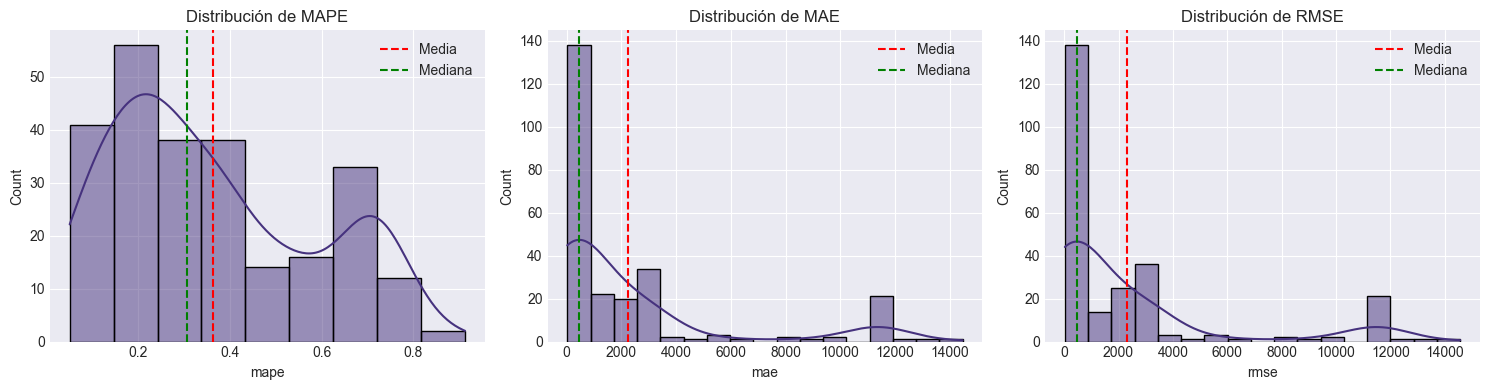

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric in zip(axes, ["mape", "mae", "rmse"]):
    sns.histplot(df_metrics[metric], kde=True, ax=ax)
    ax.set_title(f"Distribución de {metric.upper()}")
    ax.axvline(df_metrics[metric].mean(), color='red', linestyle='--', label='Media')
    ax.axvline(df_metrics[metric].median(), color='green', linestyle='--', label='Mediana')
    ax.legend()

plt.tight_layout()
plt.show()


Se mira la distribución de los errores en los 50 trials definidos para la función de optimización. 
- Logra verse que en los tres casos la media es mayor que la mediana, con algunos caos particulares mostrando errores relativamente altos en comparación con los errores promedio. Particularmente en el mape se logra ver que la mayoría de los errores están concentrados en el rango de 0 a 0.15, 

In [24]:
summary = df_metrics.groupby("trial")[["mape", "mae", "rmse"]].agg(["mean", "std"])
summary.columns = ["_".join(col) for col in summary.columns]
summary = summary.sort_values("mape_mean")
summary.head()


,mape_mean,mape_std,mae_mean,mae_std,rmse_mean,rmse_std
trial,,,,,,
47,0.178196,0.117052,884.250382,1061.038007,958.011523,1136.345215
37,0.180871,0.124409,955.216511,1179.314473,1029.401049,1250.312820
38,0.196840,0.115097,959.874638,1159.217549,1030.586029,1223.983598
42,0.199413,0.109215,922.381753,1073.967802,998.351102,1151.172481
31,0.199697,0.103874,1018.660734,1255.871037,1087.528566,1321.687735


In [25]:
# se ajustan los datos usados en los folds para pasarselos al modelo
# instanciado con los mejores parámetros.
# ademas se requiere el tener acceso a los datos de entrenamiento para poder
# obtener los rezagos dados por el proceso de optimización para el conjunto de datos de 
# prueba
X_data, y_data = create_dataset(scaled_data_folds, study.best_params["input_timesteps"])
#X = X.reshape(X.shape[0], X.shape[1], 1) - casp una variable
X_data = X_data.reshape(X_data.shape[0], X_data.shape[1], X_data.shape[2])
X_data[0]

array([[0.01354362, 0.04918745]])

In [26]:
# se organizan los datos de prueba.
# se toman los rezagos dados por los mejores hiperparametros del modelo para poder 
# tener los rezagos necesarios para hacer las primeras predicciones sobre los datos de 
# prueba
lags = study.best_params["input_timesteps"]
combined = np.concatenate([scaled_data_folds[-lags:], scaled_data_val])

# se crean y formatean los datos de prueba
X_val, y_val = create_dataset(combined, lags)
# X_val = X_val.reshape(X_val.shape[0], X_val.reshape[1], 1) - para una sola feature
X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], X_val.shape[2])
X_val[0]

array([[0.87744788, 0.99355814]])

Al instanciar el modelo, fijarlo a los datos de train y hacer las predicciones, se notó que se cada vez que se fijaba el modelo (sin reejecutar la optimización de la función con optuna), se mostraban ligeras variaciones respecto a las métricas finales. Por ello la siguiente celda fija un mismo modelo varias veces con los mismos parámetros dados por la función optimizada, grafica las predicciones vs los valores reales y mira los errores. Esto con el fin de ver si esas variaciones dadas son o no significativas. La lista de errores (mape, mae rmse) respecto a los datos de validación se guardan para ver su comportamiento y si hay desviaciones significativas

In [27]:
# se instancia el modelo
model = build_rnn(
    input_timesteps=study.best_params["input_timesteps"],
    n_features=X_val.shape[-1],
    units=study.best_params["units"],
    lr=study.best_params["lr"]
)

# número de iteraciones en las que se fija el modelo
lista_errores = []
iters = 1

for i in range(iters):
    model.fit(
        X_data, y_data, # se fija el modelo a los datos de entrenamiento
        epochs = study.best_params["epochs"],
        shuffle=False, # evita muestreo aleatorio de los datos
        batch_size = study.best_params["batch_size"],
        verbose=0
    )

    # se crean las predicciones
    forecasts = model.predict(X_val)
    
    if X_val.shape[2] == 1:
        forecast_rescaled = scaler.inverse_transform(forecasts)
    
    else: 
        forecast_rescaled = scaler.inverse_transform(
            np.hstack(
                [forecasts, np.zeros((len(forecasts), X_val.shape[2] - 1))])
        )[:, 0]
        # de nuevo, la transformación de las variables se hizo en conjunto, por lo que 
        # hay dos columnas en los datos de validación. 
        # para usar el escalado inverso, se requiere que los datos a usar tengan las mismas
        # dimensiones que los datos originales. Por lo que a la columna de predicciones
        # se le añade una "columna" con ceros antes de reescalar y luego se toma solo la 
        # primera columna
    
    # ahora se evaluan los errores
    y_true = val_data["NVDA"].values
    mape_iter = mean_absolute_percentage_error(y_true[-len(forecast_rescaled):], forecast_rescaled)
    mae_iter = mean_absolute_error(y_true[-len(forecast_rescaled):], forecast_rescaled)
    rmse_iter = float(np.sqrt(mean_squared_error(y_true[-len(forecast_rescaled):], forecast_rescaled)))

    # se añaden los errores y las predicciones dadas por los modelos como registros de 
    # la lista, para graficar y ver errores por iteración
    lista_errores.append({
        "iter": i + 1,
        "mae": mae_iter,
        "mape": mape_iter,
        "rmse": rmse_iter,
        "forecasts": forecast_rescaled,
    })



4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


In [28]:
# Cálculo de métricas agregadas

mape_median = np.median([x["mape"] for x in lista_errores])
mae_median  = np.median([x["mae"] for x in lista_errores])
rmse_median = np.median([x["rmse"] for x in lista_errores])

# Convertir las predicciones a lista nativa (para que sea JSON serializable)
predictions_list = np.asarray(lista_errores[-1]["forecasts"]).astype(float).ravel().tolist()

# Crear el DataFrame medians_df
medians_df = pd.DataFrame({
    "mape_median": [mape_median],
    "mae_median": [mae_median],
    "rmse_median": [rmse_median],
    "predictions": [predictions_list]  # lista dentro de una celda
})

# Exportar a JSON sin error
medians_df.to_json("../data/best_parameters/preds_rnn.json", orient="records")

In [29]:
# se imprimen los errores por iteracion
for el in lista_errores:
    print(f"errores iteracion {el['iter']}: \n")
    print(f"mae iter {el['iter']}: {el['mae']}")
    print(f"mape iter {el['iter']}: {el['mape']}")
    print(f"rmse iter {el['iter']}: {el['rmse']}")

errores iteracion 1: 

mae iter 1: 5.810019496835257
mape iter 1: 0.049625665338762885
rmse iter 1: 7.524509827826007


In [30]:
lista_errores

[{'iter': 1,
  'mae': 5.810019496835257,
  'mape': 0.049625665338762885,
  'rmse': 7.524509827826007,
  'forecasts': array([134.06262493, 132.80698903, 132.27663113, 133.79607608,
         136.87803183, 140.7073481 , 140.87513263, 140.65604643,
         138.59451326, 139.23892592, 136.74018832, 140.05040124,
         144.57051003, 148.16467861, 141.34080153, 141.28008279,
         138.28315953, 136.0488544 , 134.79941998, 138.05641171,
         135.9221834 , 139.05332444, 141.31804636, 145.96170901,
         145.9434655 , 142.50436677, 122.46373849, 131.55023751,
         127.08272646, 127.78700474, 123.84274778, 120.92547582,
         122.56832697, 127.98422169, 131.2210176 , 132.44243052,
         135.39776449, 134.75157998, 133.43278084, 136.61200797,
         139.48567269, 139.86210917, 139.66759922, 140.47341445,
         136.3231305 , 132.988489  , 129.98310021, 133.94043278,
         124.64291934, 128.49927276, 119.10376607, 121.18528179,
         122.1302038 , 116.25923847, 118

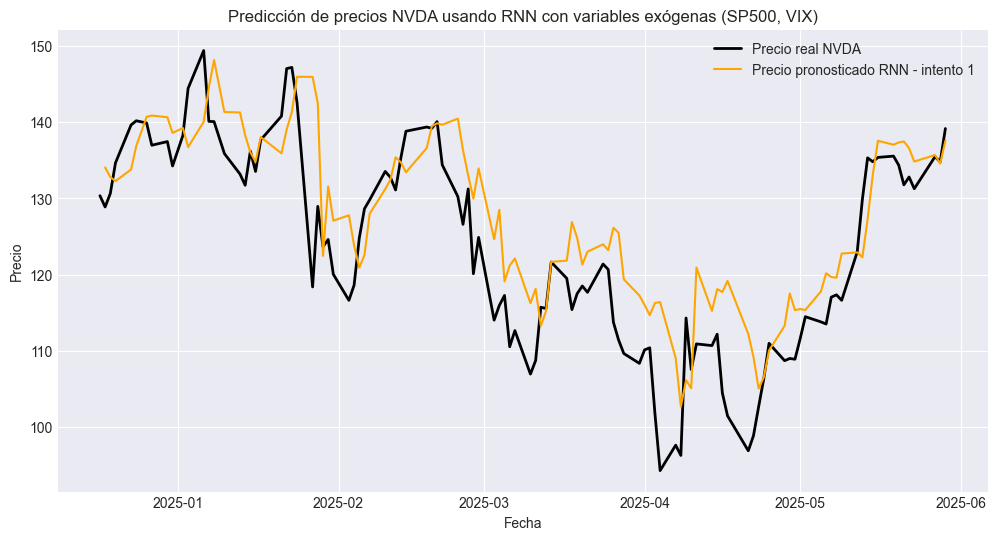

In [31]:
# se grafican los datos de prueba vs los pronosticos dados en cada una de las iters
#112
plt.figure(figsize=(12,6))
#plt.plot(df_data_close["Date"][:-len(X_data_test)], df_data_close["NVDA"][:-len(X_data_test)], label="Precio real NVDA - train", color="gray")
plt.plot(val_data["Date"][-len(val_data):], val_data["NVDA"][-len(val_data):], label="Precio real NVDA", color="black", alpha=1, linewidth=2)
for i, resultado in enumerate(lista_errores):
    forecast_rescaled = resultado["forecasts"]
    plt.plot(val_data["Date"][-len(forecast_rescaled):], forecast_rescaled, label=f"Precio pronosticado RNN - intento {i+1}", alpha=1, color='orange')
#plt.plot(val_data["Date"][-len(predictions_rescaled):], predictions_rescaled, label="Precio pronosticado RNN", color="orange")
#plt.plot(train_data["Date"], train_data["NVDA"], label="train", color="gray")
#plt.plot(test_data["Date"], test_data["NVDA"], label="test", color="orange")
#plt.axvline(fecha_corte, color="black", linestyle="-")
plt.title("Predicción de precios NVDA usando RNN con variables exógenas (SP500, VIX)")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()
plt.show()

In [32]:
# se toman los valores promedio de cada una de las medidas
list_mapes, list_maes, list_rmses = [], [], []
for el in lista_errores:
    list_mapes.append(el["mape"])
    list_maes.append(el["mae"])
    list_rmses.append(el["rmse"])
print(f"mape prom validacion: {np.mean(list_mapes)}")
print(f"mae prom validacion: {np.mean(list_maes)}")
print(f"rmse prom validacion: {np.mean(list_rmses)}")

mape prom validacion: 0.049625665338762885
mae prom validacion: 5.810019496835257
rmse prom validacion: 7.524509827826007
